# Evaluación 2 — Reconstrucción con red neuronal y capa de Fourier
**Programación Científica 2026-1 · Universidad Nacional de Colombia**

**Estudiante:** Juan Camilo Castaño Chavarriaga

**Cédula:** 1034991170

---

## Pregunta guía
> ¿Conviene inicializar la primera capa de la red en la **base de Fourier** en lugar de una **base aleatoria** para reconstruir señales de un medio dispersivo?

Aquí crearemos una red $\hat x = W_2\,\tanh(W_1 x)$ con $x\in\mathbb{R}^{256}$, $K=15$ frecuencias, y la entrenaremos sobre los **tres regímenes** del medio ($\mu\in\{0,5,15\}$) con las **dos inicializaciones de $W_1$**, compararemos sus resultados, analizaremos la utilidad de las distintas inicializaciones y además llevaremos a cabo un experimento adicional nacido de querer entender la interacción de una red neuronal y los conceptos relacionados a la transformada de Fourier discreta.

## 0. Imports y estilo del proyecto

**En esta celda** importamos las librerías (NumPy, Matplotlib, JAX), fijamos la semilla global, definimos **un único estilo por defecto** para todas las figuras y creamos dos ayudantes de dibujo (`barra_color`, `dibujar_original`).

El estilo busca:

- **Fuente tipo LaTeX** (STIX): serif con matemáticas a juego.
- **Todo el texto de una figura al mismo tamaño** (`TAM_FUENTE`): títulos, ejes, ticks, leyendas y anotaciones.
- **Líneas gruesas** estilo presentación y **colorbars uniformes** (helper `barra_color`).
- Paleta **cualitativa** fija por régimen y colormap **secuencial** (`viridis`) para datos escalares.

In [ ]:
# ============================================================
#  IMPORTS Y CONFIGURACIÓN GLOBAL
# ============================================================
import numpy as np                     # cálculo numérico en CPU
import matplotlib.pyplot as plt         # figuras
import jax                              # autodiferenciación + JIT (el "motor" de la red)
import jax.numpy as jnp                 # versión de numpy que JAX sabe derivar
from jax import grad, jit, value_and_grad, random

# JAX usa float32 por defecto; lo subimos a float64 para tener precisión de "máquina"
# (importante para verificar identidades como W1 x == DFT o Parseval).
jax.config.update("jax_enable_x64", True)

SEMILLA = 1170                          # semilla global (coincide con el ID del enunciado)

# ============================================================
#  ESTILO DEL PROYECTO — se aplica a TODAS las figuras
# ============================================================
TAM_FUENTE = 13   # tamaño ÚNICO de texto para toda figura (títulos, ejes, ticks, leyenda...)

plt.rcParams.update({
    # --- fuente tipo LaTeX (STIX: serif + matemáticas a juego + acentos) ---
    "mathtext.fontset":  "stix",
    "font.family":       "STIXGeneral",
    "axes.unicode_minus": True,
    # --- TODOS los textos al mismo tamaño ----------------------------------
    "font.size":         TAM_FUENTE,
    "axes.titlesize":    TAM_FUENTE,
    "axes.labelsize":    TAM_FUENTE,
    "xtick.labelsize":   TAM_FUENTE,
    "ytick.labelsize":   TAM_FUENTE,
    "legend.fontsize":   TAM_FUENTE,
    "figure.titlesize":  TAM_FUENTE,
    # --- líneas gruesas (estilo presentación) ------------------------------
    "lines.linewidth":   2.6,
    "lines.markersize":  6,
    "axes.linewidth":    1.1,
    # --- rejilla, marco, fondo ---------------------------------------------
    "figure.dpi":        120,
    "savefig.dpi":       120,
    "savefig.bbox":      "tight",
    "axes.grid":         True,
    "grid.alpha":        0.25,
    "grid.linewidth":    0.8,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
    "legend.frameon":    False,
})

# Paleta CUALITATIVA por régimen (3 categorías bien separadas, colores de alto contraste)
COLOR_REG = {0: "#1b6ca8", 1: "#e08b00", 2: "#b8002b"}
NOMBRE_REG = {0: r"Régimen 0 — sin dispersión ($\mu=0$)",
              1: r"Régimen 1 — intermedia ($\mu=5$)",
              2: r"Régimen 2 — fuerte ($\mu=15$)"}
COLOR_FOURIER = "#1b6ca8"   # trazo principal (inicialización Fourier)
COLOR_RANDOM  = "0.55"      # gris: base de comparación (inicialización aleatoria)
CMAP_SECUENCIAL = "viridis" # colormap para datos escalares (de bajo a alto)

def barra_color(fig, mappable, ax, etiqueta):
    """Añade una colorbar con proporciones uniformes en todo el proyecto."""
    cb = fig.colorbar(mappable, ax=ax, fraction=0.046, pad=0.04)
    cb.set_label(etiqueta)
    return cb

def dibujar_original(ax, tiempo, senal, color="k", label="original (interpolada)"):
    """Dibuja la señal ORIGINAL dentro de una comparación:
    interpolación continua + puntos de muestra (mismo color, un poco más grandes,
    siempre al fondo con zorder bajo) para que la reconstrucción se pinte encima."""
    ax.plot(tiempo, senal, marker="o", linestyle="-", color=color, lw=1.3,
            markersize=4.5, zorder=1, label=label)

print("JAX:", jax.__version__, "| backend:", jax.default_backend())
print(f"Estilo del proyecto activo · tamaño de texto uniforme = {TAM_FUENTE}")

# Parte I — Los datos

## 1.1 Carga e inspección
Cada señal tiene 256 muestras en $t\in[0,1)$ s. Hay 8 señales por régimen (24 en total).

**En esta celda** cargamos el archivo `datos_1170.npz`, extraemos los tres arrays (`senales`, `regimenes`, `tiempo`), calculamos los parámetros de muestreo (paso temporal, frecuencia de muestreo y frecuencia de Nyquist) e imprimimos un resumen para confirmar las dimensiones.

In [ ]:
# Cargamos el contenedor .npz (varios arrays con nombre dentro de un solo archivo)
datos = np.load("datos_1170.npz")

senales   = datos["X"].astype(np.float64)   # (24, 256): 24 señales, cada una de 256 muestras
regimenes = datos["y"].astype(np.int64)     # (24,)   : régimen (0, 1 o 2) de cada señal
tiempo    = datos["t"].astype(np.float64)   # (256,)  : instantes de muestreo, compartidos

# Parámetros de muestreo (derivados del eje de tiempo)
n_muestras     = senales.shape[1]               # 256 muestras por señal
paso_temporal  = float(tiempo[1] - tiempo[0])   # Δt entre muestras [s]
frec_muestreo  = 1.0 / paso_temporal            # fs = 1/Δt [Hz]

# Resumen de dimensiones y muestreo
print(f"senales: {senales.shape}  ·  regimenes: {regimenes.shape}  ·  tiempo: {tiempo.shape}")
print(f"Δt = {paso_temporal:.5f} s  ->  fs = {frec_muestreo:.1f} Hz   "
      f"(Nyquist = {frec_muestreo/2:.1f} Hz)")
for r in (0, 1, 2):
    print(f"  régimen {r}: {(regimenes == r).sum()} señales")

### Estructura interna del archivo `.npz`

Un `.npz` no es una sola tabla, sino un **contenedor de varios *arrays* con nombre**. Para verlo con claridad lo presentamos al estilo de un `DataFrame` de pandas.

**En esta celda** mostramos tres tablas: (1) el **esquema** (qué arrays hay, con su forma y tipo), (2) los **datos como tabla** (cada fila es una señal, con su etiqueta de régimen coloreada y sus 256 muestras) y (3) los **metadatos**.

In [ ]:
import pandas as pd
from IPython.display import display, Markdown

pd.set_option("styler.render.max_columns", 8)   # resume las 256 columnas con "…"

# --- 1) ESQUEMA: qué arrays contiene el .npz, con su forma y tipo ---
esquema = pd.DataFrame(
    [("X",    str(senales.shape),   str(senales.dtype),   "señales medidas (24 filas × 256 muestras)"),
     ("y",    str(regimenes.shape), str(regimenes.dtype), "régimen de cada señal: 0, 1 o 2"),
     ("t",    str(tiempo.shape),    str(tiempo.dtype),    "instantes de tiempo, compartidos por todas [s]"),
     ("meta", str(datos["meta"].shape), str(datos["meta"].dtype), "metadatos: ID, huella del equipo, fecha")],
    columns=["clave", "forma", "dtype", "qué contiene"],
).set_index("clave")
display(Markdown("**1) Esquema del `.npz`** — los cuatro arrays que contiene:"))
display(esquema)

# --- 2) DATOS COMO TABLA: una fila por señal = etiqueta (régimen) + 256 muestras ---
columnas_tiempo = [f"t={ti:.3f}" for ti in tiempo]     # nombre de cada columna = instante de tiempo
tabla_datos = pd.DataFrame(senales, columns=columnas_tiempo)
tabla_datos.insert(0, "régimen", regimenes)            # etiqueta como primera columna
tabla_datos.index.name = "señal #"

def _color_regimen(valor):
    # colorea la celda de 'régimen' con la paleta del proyecto
    return f"background-color: {COLOR_REG[valor]}; color: white; font-weight: bold"

tabla_estilizada = (tabla_datos.style
    .map(_color_regimen, subset=["régimen"])
    .format("{:.3f}", subset=columnas_tiempo)
    .set_caption("Cada fila es una señal: su etiqueta 'régimen' y sus 256 muestras de "
                 "amplitud (columnas = tiempo en s). El '…' resume las columnas centrales."))
display(Markdown("**2) Los datos como tabla** — 24 señales (filas) × 256 muestras (columnas), con su etiqueta:"))
display(tabla_estilizada)

# --- 3) METADATOS: información de trazabilidad guardada al generar los datos ---
meta = datos["meta"]
tabla_meta = pd.DataFrame(
    {"valor": [meta[0], meta[1], meta[2]]},
    index=pd.Index(["ID (últimos 4 dígitos de la cédula)",
                    "huella del equipo que generó los datos",
                    "fecha de generación"], name="meta"),
)
display(Markdown("**3) Metadatos** (`meta`):"))
display(tabla_meta)

## 1.2 Visualización de señales por régimen
Para entender los datos con los que se está trabajando, mostramos una señal representativa de cada régimen.

**En esta celda** graficamos, en tres paneles apilados, la primera señal de cada régimen como **muestras discretas** (un punto por muestra), para recordar que la entrada es una señal muestreada.

In [ ]:
# Un panel por régimen: mostramos la PRIMERA señal de cada uno como muestras discretas
fig, axes = plt.subplots(3, 1, figsize=(8.5, 6.8), sharex=True)
for ax, reg in zip(axes, (0, 1, 2)):
    indice = np.where(regimenes == reg)[0][0]        # índice de la 1ª señal de este régimen
    ax.plot(tiempo, senales[indice], marker="o", linestyle="none", markersize=2.8,
            color=COLOR_REG[reg])                     # solo puntos = señal discreta
    ax.set_ylabel("amplitud")
    ax.set_title(NOMBRE_REG[reg], loc="left")
axes[-1].set_xlabel(r"tiempo  $t$")
fig.suptitle("Señales medidas", y=1.0)
fig.tight_layout()
plt.show()

## 1.3 Espectro: dónde vive cada régimen
Visualizamos $|\mathrm{FFT}(x)|$ para una señal típica de cada régimen y marcamos la **frecuencia máxima $K=15$ Hz** que la capa Fourier podrá representar.

**En esta celda** definimos la constante `K = 15` (número de frecuencias de la capa), calculamos el eje de frecuencias con `rfftfreq`, y dibujamos el espectro de amplitud de una señal por régimen como **stem discreto** (con una silueta tenue de fondo). La línea vertical señala el corte $K=15$.

In [ ]:
K = 15                                   # número de frecuencias que tendrá la capa Fourier
frecuencias = np.fft.rfftfreq(n_muestras, d=paso_temporal)   # eje de frecuencias de la FFT real [Hz]

fig, ax = plt.subplots(figsize=(9.5, 4.6))
banda_visible = frecuencias <= 30                # solo mostramos hasta 30 Hz (ahí está la acción)
for reg in (0, 1, 2):
    indice = np.where(regimenes == reg)[0][0]    # 1ª señal del régimen
    espectro = np.abs(np.fft.rfft(senales[indice]))   # magnitud del espectro |FFT|

    # (a) silueta tenue: recta entre puntos (no suave), por detrás de los stems
    ax.plot(frecuencias[banda_visible], espectro[banda_visible],
            color=COLOR_REG[reg], lw=1.1, alpha=0.30, zorder=1)
    # (b) espectro discreto: un "stem" (línea vertical + punto) por frecuencia
    marcadores, tallos, base = ax.stem(frecuencias[banda_visible], espectro[banda_visible], basefmt=" ")
    plt.setp(tallos, color=COLOR_REG[reg], lw=1.1, alpha=0.9)
    plt.setp(marcadores, color=COLOR_REG[reg], markersize=4)

ax.axvline(K, color="k", ls="--", lw=1.4)         # corte de la capa Fourier (K = 15 Hz)
ax.set_xlim(-0.5, 30)
ax.set_xlabel("frecuencia  [Hz]")
ax.set_ylabel(r"$|\mathrm{FFT}(x)|$")
ax.set_title("Espectro de amplitud por régimen", loc="left")

# Leyenda construida a mano (los stem no generan una entrada de leyenda limpia)
from matplotlib.lines import Line2D
handles = [Line2D([0], [0], color=COLOR_REG[r], lw=2.4, marker="o", ms=5,
                  label=NOMBRE_REG[r]) for r in (0, 1, 2)]
handles.append(Line2D([0], [0], color="k", ls="--", lw=1.4,
                      label=fr"$K={K}$ Hz — alcance de la capa Fourier"))
ax.legend(handles=handles, loc="upper right")
fig.tight_layout()
plt.show()

**Observación crítica.** Los picos espectrales del **régimen 2** ($\mu=15$) caen entre **15 y 19 Hz**, *justo en o por encima* del corte de la capa Fourier. Esto va a marcar la respuesta a la pregunta guía: la base Fourier sólo ayuda cuando la señal vive dentro de la banda que esa base cubre.

## 1.4 Panorama espectral completo (heatmap)
Para ver las 24 señales de un vistazo, apilamos sus espectros $|\mathrm{FFT}|$ en un mapa de calor. Colormap **secuencial** (`viridis`, de bajo a alto).

**En esta celda** ordenamos las señales por régimen, calculamos el espectro de todas de una vez, y las dibujamos como una imagen (`imshow`): cada fila es una señal, el eje horizontal la frecuencia. Las líneas blancas separan los regímenes y la vertical marca el corte $K=15$.

In [ ]:
# Reordenamos las señales para que queden agrupadas por régimen (0, luego 1, luego 2)
orden = np.argsort(regimenes, kind="stable")
espectros = np.abs(np.fft.rfft(senales[orden], axis=1))   # |FFT| de las 24 señales a la vez
banda_visible = frecuencias <= 30

fig, ax = plt.subplots(figsize=(9, 5.2))
# Mapa de calor: filas = señales (agrupadas por régimen), columnas = frecuencia
imagen = ax.imshow(espectros[:, banda_visible], aspect="auto", origin="lower",
                   cmap=CMAP_SECUENCIAL,
                   extent=[frecuencias[banda_visible][0], frecuencias[banda_visible][-1],
                           0, len(orden)])

# Separadores blancos entre regímenes y etiqueta de cada grupo en el eje y
regimenes_ordenados = regimenes[orden]
fronteras = np.where(np.diff(regimenes_ordenados) != 0)[0] + 1
for f in fronteras:
    ax.axhline(f, color="white", lw=1.2)
centros = [np.mean(np.where(regimenes_ordenados == r)[0]) + 0.5 for r in (0, 1, 2)]
ax.set_yticks(centros)
ax.set_yticklabels([f"Rég. {r}" for r in (0, 1, 2)])

ax.axvline(K, color="w", ls="--", lw=1.4)                 # corte de la capa Fourier
ax.text(K + 0.4, len(orden) - 1.5, f"$K={K}$", color="w", va="top")
ax.set_xlabel("frecuencia  [Hz]")
ax.set_title("Espectros de las 24 señales agrupadas por régimen", loc="left")
ax.grid(False)
barra_color(fig, imagen, ax, r"$|\mathrm{FFT}(x)|$")     # colorbar uniforme del proyecto
fig.tight_layout()
plt.show()

# Parte II — La capa Fourier

## 2.1 Construcción de $W_1$
Para cada $k=1,\dots,15$ tomamos dos filas — un coseno y un seno — escaladas por $2/N$ (factor de la DFT en amplitudes):

$$\bigl(W_1^{\text{Fourier}}\bigr)_{2k-2,\,n}=\tfrac{2}{N}\cos(2\pi k\,t_n),\qquad
\bigl(W_1^{\text{Fourier}}\bigr)_{2k-1,\,n}=\tfrac{2}{N}\sin(2\pi k\,t_n).$$

Sin este factor $W_1 x$ alcanzaría valores $\sim N/2$ y la $\tanh$ se saturaría desde la iteración 0 (gradiente nulo).

**En esta celda** definimos la función `matriz_fourier` que arma esa matriz, construimos `W1_fourier` y graficamos algunas de sus filas para comprobar que son senos y cosenos.

In [ ]:
def matriz_fourier(tiempo, K, escala):
    """Construye la matriz de la capa Fourier (2K filas × n_muestras columnas).
    Intercala una fila coseno y una seno por cada frecuencia k = 1..K,
    escaladas por 'escala' (usamos 2/N para reproducir las amplitudes de la DFT)."""
    k_indices = np.arange(1, K + 1)[:, None]                 # frecuencias k = 1..K (columna)
    filas_coseno = escala * np.cos(2 * np.pi * k_indices * tiempo)   # (K, n_muestras)
    filas_seno   = escala * np.sin(2 * np.pi * k_indices * tiempo)   # (K, n_muestras)
    W1 = np.empty((2 * K, tiempo.size))
    W1[0::2] = filas_coseno    # filas pares  -> cosenos
    W1[1::2] = filas_seno      # filas impares -> senos
    return W1

# Matriz de la capa Fourier con la escala 2/N (amplitudes de la DFT)
W1_fourier = matriz_fourier(tiempo, K, escala=2.0 / n_muestras)
print("W1_fourier shape:", W1_fourier.shape,
      "·  norma euclídea por fila:", f"{np.linalg.norm(W1_fourier[0]):.4f}")

# Dibujamos algunas filas (cos y sin para k=1 y k=5) para verlas como sinusoides
fig, ax = plt.subplots(figsize=(9, 3.8))
for k_mostrar in (1, 5):
    fila_coseno = 2 * (k_mostrar - 1)     # posición de la fila coseno de esa k
    fila_seno   = fila_coseno + 1         # la fila seno va justo después
    ax.plot(tiempo, W1_fourier[fila_coseno], lw=2.4, label=fr"$\cos$, $k={k_mostrar}$")
    ax.plot(tiempo, W1_fourier[fila_seno], lw=2.4, ls="--", label=fr"$\sin$, $k={k_mostrar}$")
ax.set_xlabel(r"$t$  [s]")
ax.set_ylabel("valor")
ax.set_title(r"Algunas filas de $W_1^{\mathrm{Fourier}}$ (escala $2/N$)", loc="left")
ax.legend(ncol=2)
fig.tight_layout()
plt.show()

## 2.2 Verificación: $W_1 x$ ES la DFT
Cada par de salidas de la capa Fourier debe coincidir, salvo el signo, con la parte real y la parte imaginaria del coeficiente DFT correspondiente:

$$\bigl(W_1 x\bigr)_{2k-2}=\tfrac{2}{N}\,\mathrm{Re}\,X_k,\qquad
\bigl(W_1 x\bigr)_{2k-1}=-\tfrac{2}{N}\,\mathrm{Im}\,X_k.$$

**En esta celda** tomamos una señal de ejemplo, le aplicamos la capa (`W1_fourier @ x`) y la DFT de NumPy, y comprobamos que coinciden hasta la precisión de máquina.

In [ ]:
# Tomamos una señal de ejemplo (la 1ª del régimen 1)
indice_ejemplo = np.where(regimenes == 1)[0][0]
senal_ejemplo  = senales[indice_ejemplo]

salida_capa  = W1_fourier @ senal_ejemplo     # (2K,): lo que produce la capa Fourier
espectro_dft = np.fft.rfft(senal_ejemplo)     # DFT de NumPy (complejo) para comparar

# La capa (escalada 2/N) debe reproducir la parte real y la imaginaria (con signo) de la DFT
real_dft  =  (2.0 / n_muestras) * espectro_dft[1:K+1].real
imag_dft  = -(2.0 / n_muestras) * espectro_dft[1:K+1].imag   # signo: e^{-i2πkt} = cos - i·sin
real_capa = salida_capa[0::2]                  # filas coseno -> parte real
imag_capa = salida_capa[1::2]                  # filas seno   -> parte imaginaria

# Máximo error entre la capa y la DFT (debe ser ~1e-15, precisión de máquina)
err_real = np.max(np.abs(real_capa - real_dft))
err_imag = np.max(np.abs(imag_capa - imag_dft))
print(f"max |Re(W1 x) - (2/N)*Re(DFT)|  = {err_real:.3e}")
print(f"max |Im(W1 x) - (-2/N)*Im(DFT)| = {err_imag:.3e}")
print("-> Coinciden (precisión de máquina): la capa Fourier, en su inicialización,")
print("   ES la DFT en amplitudes.")

In [ ]:
# Comparación visual: coeficientes de la capa (x) vs. los de NumPy (o), parte real e imaginaria
k_indices = np.arange(1, K + 1)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)

axes[0].stem(k_indices - 0.12, real_dft, linefmt="C0-", markerfmt="C0o", basefmt=" ",
             label=r"$(2/N)\,\mathrm{Re}\,X_k$ (numpy.fft)")
axes[0].stem(k_indices + 0.12, real_capa, linefmt="C3-", markerfmt="C3x", basefmt=" ",
             label=r"$(W_1 x)_{2k-2}$")
axes[0].set_title(r"Parte real")
axes[0].set_xlabel(r"$k$")
axes[0].set_ylabel("valor")
axes[0].legend()

axes[1].stem(k_indices - 0.12, imag_dft, linefmt="C0-", markerfmt="C0o", basefmt=" ",
             label=r"$-(2/N)\,\mathrm{Im}\,X_k$")
axes[1].stem(k_indices + 0.12, imag_capa, linefmt="C3-", markerfmt="C3x", basefmt=" ",
             label=r"$(W_1 x)_{2k-1}$")
axes[1].set_title(r"Parte imaginaria (con signo)")
axes[1].set_xlabel(r"$k$")
axes[1].legend()

fig.suptitle("La capa Fourier inicial coincide con la DFT", y=1.02)
fig.tight_layout()
plt.show()

# Parte III — La red y el entrenamiento

$$\hat x = W_2\,\tanh(W_1 x),\qquad W_1\in\mathbb{R}^{2K\times N},\ W_2\in\mathbb{R}^{N\times 2K}.$$

Pérdida MSE por muestra:

$$\mathcal{L}(W_1,W_2)=\frac1N\|\hat x - x\|^2.$$

**Decisiones del experimento.**

- *Inicialización de $W_1$:* Fourier (escalada $2/N$) **vs.** aleatoria $\mathcal{N}(0,\sigma^2)$ con $\sigma=\sqrt2/N$ para que sus filas tengan la **misma norma** que las de Fourier — comparación justa.
- *Inicialización de $W_2$:* la misma para ambos modelos (compartida) y **pequeña** ($\sigma_{W_2}=0.01$). Así $\hat x(0)\approx 0$ y la pérdida inicial es $\approx\mathrm{var}(x)$ — *idéntica* para los dos. Las trayectorias parten del mismo punto y cualquier diferencia se atribuye al *punto de partida de $W_1$*.
- *Optimizador:* **SGD con momento** ($\beta=0.9$), $\eta=0.05$ — el momento es estándar y necesario para que el SGD converja en 3000 iteraciones con este $\eta$ tan pequeño.
- *Reducción de varianza:* repetimos con **3 semillas** distintas (afectan a $W_2$ y a $W_1^{\text{rand}}$). Reportamos media y dispersión.

**En esta celda** definimos las piezas del entrenamiento: la propagación de la red (`propagar`), la pérdida (`perdida_mse`), un paso de descenso por gradiente con momento (`paso_sgd`), las dos inicializaciones y el bucle `entrenar`.

In [ ]:
# ---------- Propagación hacia adelante y pérdida ---------------------------
def propagar(params, entradas):
    """Pasa las señales por la red: x_hat = W2 · tanh(W1 · x)."""
    W1, W2 = params
    oculta = jnp.tanh(entradas @ W1.T)   # (n, 2K): activaciones de la capa oculta (tanh)
    return oculta @ W2.T                  # (n, N): reconstrucción de las señales

def perdida_mse(params, entradas):
    """Error cuadrático medio entre la reconstrucción y la señal original."""
    return jnp.mean((propagar(params, entradas) - entradas) ** 2)

# ---------- Un paso de SGD con momento (compilado con @jit para ir rápido) -----
@jit
def paso_sgd(params, velocidad, entradas, lr=0.05, beta=0.9):
    valor, gradientes = value_and_grad(perdida_mse)(params, entradas)   # pérdida y su gradiente
    nueva_velocidad = tuple(beta * v + g for v, g in zip(velocidad, gradientes))  # momento
    nuevos_params   = tuple(p - lr * v for p, v in zip(params, nueva_velocidad))  # actualización
    return nuevos_params, nueva_velocidad, valor

# ---------- Inicializaciones de los pesos ----------------------------------
SIGMA_W1_RANDOM = np.sqrt(2.0) / n_muestras   # iguala la norma de fila de la matriz Fourier
SIGMA_W2        = 0.01                         # pequeño: x_hat(0) ≈ 0  ->  L(0) ≈ var(x)

def inicializar_fourier(tiempo, K, clave_w2):
    """W1 = matriz de Fourier (escala 2/N); W2 = ruido pequeño (misma clave para comparar justo)."""
    W1 = jnp.asarray(matriz_fourier(np.asarray(tiempo), K, escala=2.0 / tiempo.size))
    W2 = random.normal(clave_w2, (tiempo.size, 2 * K)) * SIGMA_W2
    return (W1, W2)

def inicializar_aleatoria(n_muestras, K, clave_w1, clave_w2):
    """W1 = ruido con norma de fila igual a la de Fourier; W2 = mismo ruido pequeño que la Fourier."""
    W1 = random.normal(clave_w1, (2 * K, n_muestras)) * SIGMA_W1_RANDOM
    W2 = random.normal(clave_w2, (n_muestras, 2 * K)) * SIGMA_W2
    return (W1, W2)

# ---------- Bucle de entrenamiento -----------------------------------------
def entrenar(params, entradas, n_iter=3000, lr=0.05):
    """Entrena por SGD con momento y devuelve los pesos finales + el historial de pérdida."""
    velocidad = tuple(jnp.zeros_like(p) for p in params)   # momento inicial en cero
    historial = np.empty(n_iter)
    for i in range(n_iter):
        params, velocidad, valor = paso_sgd(params, velocidad, entradas, lr=lr)
        historial[i] = float(valor)
    return params, historial

## 3.1 Entrenamiento: 3 regímenes × 2 inicializaciones × 3 semillas
3000 iteraciones con $\eta=0.05$. Guardamos toda la historia para analizar la dinámica.

**En esta celda** corremos el experimento completo: para cada semilla y cada régimen entrenamos dos redes (init Fourier y aleatoria, con el mismo $W_2$), guardamos las curvas de pérdida en `resultados` y los pesos finales, e imprimimos un resumen.

In [ ]:
N_ITER, LR, N_SEEDS = 3000, 0.05, 3   # iteraciones, learning rate, nº de semillas

# resultados[regimen][init]["loss"] = matriz (N_SEEDS, N_ITER) con la curva de pérdida
resultados = {r: {"fourier": {"loss": np.zeros((N_SEEDS, N_ITER))},
                  "random":  {"loss": np.zeros((N_SEEDS, N_ITER))}}
              for r in (0, 1, 2)}

for s in range(N_SEEDS):
    clave = random.PRNGKey(SEMILLA + s)
    clave_w1_rand, clave_w2 = random.split(clave)   # W2 se comparte entre ambas inicializaciones
    for reg in (0, 1, 2):
        senales_reg = jnp.asarray(senales[regimenes == reg])    # las 8 señales del régimen
        params_fourier = inicializar_fourier(tiempo, K, clave_w2)
        params_random  = inicializar_aleatoria(n_muestras, K, clave_w1_rand, clave_w2)

        params_fourier_final, hist_fourier = entrenar(params_fourier, senales_reg, N_ITER, LR)
        params_random_final,  hist_random  = entrenar(params_random,  senales_reg, N_ITER, LR)

        resultados[reg]["fourier"]["loss"][s] = hist_fourier
        resultados[reg]["random"]["loss"][s]  = hist_random
        if s == N_SEEDS - 1:   # guardamos los pesos finales de la última semilla para reconstruir
            resultados[reg]["fourier"]["params_last"] = params_fourier_final
            resultados[reg]["random"]["params_last"]  = params_random_final

# Resumen: pérdida inicial (L0) y final (media sobre semillas) de cada inicialización
print("Resumen (media sobre semillas):")
print(f"{'reg':>3} {'L0':>8} {'L_final_F':>10} {'L_final_R':>10}")
for reg in (0, 1, 2):
    L_inicial       = resultados[reg]["fourier"]["loss"][:, 0].mean()
    L_final_fourier = resultados[reg]["fourier"]["loss"][:, -1].mean()
    L_final_random  = resultados[reg]["random"]["loss"][:, -1].mean()
    print(f"{reg:>3} {L_inicial:>8.4f} {L_final_fourier:>10.2e} {L_final_random:>10.2e}")

## 3.2 La idea en una figura
Régimen 0 (donde la base Fourier apunta a las frecuencias correctas): línea gruesa = media sobre semillas, líneas finas = las 3 corridas individuales, y **anotación del mensaje**.

**En esta celda** dibujamos, para el régimen 0 y las primeras 300 iteraciones, las curvas de pérdida de ambas inicializaciones (media + corridas individuales) con una flecha que señala la ventaja temprana de Fourier.

In [ ]:
reg = 0
perdidas_fourier = resultados[reg]["fourier"]["loss"]   # (N_SEEDS, N_ITER)
perdidas_random  = resultados[reg]["random"]["loss"]
iteraciones = np.arange(N_ITER)
media_fourier = perdidas_fourier.mean(0)
media_random  = perdidas_random.mean(0)

fig, ax = plt.subplots(figsize=(9, 5))
n_zoom = 300     # nos fijamos en las primeras 300 iteraciones (la fase decisiva)

# Las 3 corridas individuales (líneas finas) + la media (línea gruesa)
for s in range(N_SEEDS):
    ax.plot(iteraciones[:n_zoom], perdidas_random[s, :n_zoom],  color=COLOR_RANDOM, lw=0.8, alpha=0.35)
    ax.plot(iteraciones[:n_zoom], perdidas_fourier[s, :n_zoom], color=COLOR_REG[reg], lw=0.8, alpha=0.35)
ax.plot(iteraciones[:n_zoom], media_random[:n_zoom],  color=COLOR_RANDOM, lw=3.0, label="inicialización aleatoria")
ax.plot(iteraciones[:n_zoom], media_fourier[:n_zoom], color=COLOR_REG[reg], lw=3.5, label="inicialización Fourier")

ax.set_xlabel("iteración")
ax.set_ylabel(r"pérdida  $\mathcal{L}$")
ax.set_title("A. Régimen 0: la base de Fourier aprende más rápido", loc="left")
ax.legend(loc="upper right")

# Anotación del mensaje (flecha al punto donde Fourier ya va por debajo)
iter_flecha = 90
texto = "Fourier ya está\npor debajo:\nmenor error\ndesde el inicio"
ax.annotate(texto,
            xy=(iter_flecha, media_fourier[iter_flecha]),
            xytext=(150, 0.42),
            color=COLOR_REG[reg], fontweight="bold",
            arrowprops=dict(arrowstyle="->", color=COLOR_REG[reg], lw=1.4))
fig.tight_layout()
plt.show()

## 3.3 Evolución de la pérdida — los tres regímenes
Línea gruesa = media sobre semillas; líneas finas = las 3 corridas individuales. Arriba: escala log, vista completa. Abajo: zoom lineal en las primeras 250 iteraciones (la fase decisiva).

**En esta celda** dibujamos una rejilla 2×3: una columna por régimen, la fila superior en escala logarítmica (toda la corrida) y la inferior en escala lineal (zoom al inicio).

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharey="row")
iteraciones = np.arange(N_ITER)
for col, reg in enumerate((0, 1, 2)):
    perdidas_fourier = resultados[reg]["fourier"]["loss"]
    perdidas_random  = resultados[reg]["random"]["loss"]
    media_fourier = perdidas_fourier.mean(0)
    media_random  = perdidas_random.mean(0)

    # --- fila superior: escala logarítmica, corrida completa ---
    ax = axes[0, col]
    for s in range(N_SEEDS):
        ax.semilogy(iteraciones, perdidas_random[s],  color=COLOR_RANDOM, lw=0.7, alpha=0.30)
        ax.semilogy(iteraciones, perdidas_fourier[s], color=COLOR_REG[reg], lw=0.7, alpha=0.30)
    ax.semilogy(iteraciones, media_random,  color=COLOR_RANDOM, lw=2.4, label="aleatoria")
    ax.semilogy(iteraciones, media_fourier, color=COLOR_REG[reg], lw=2.8, label="Fourier")
    ax.set_title(NOMBRE_REG[reg], loc="left")
    ax.set_xlabel("iteración")
    ax.legend()

    # --- fila inferior: escala lineal, zoom a las primeras 250 iteraciones ---
    ax2 = axes[1, col]
    n_zoom = 250
    for s in range(N_SEEDS):
        ax2.plot(iteraciones[:n_zoom], perdidas_random[s, :n_zoom],  color=COLOR_RANDOM, lw=0.7, alpha=0.30)
        ax2.plot(iteraciones[:n_zoom], perdidas_fourier[s, :n_zoom], color=COLOR_REG[reg], lw=0.7, alpha=0.30)
    ax2.plot(iteraciones[:n_zoom], media_random[:n_zoom],  color=COLOR_RANDOM, lw=2.4, label="aleatoria")
    ax2.plot(iteraciones[:n_zoom], media_fourier[:n_zoom], color=COLOR_REG[reg], lw=2.8, label="Fourier")
    ax2.set_xlabel("iteración (zoom)")
    ax2.legend()

axes[0, 0].set_ylabel(r"$\mathcal{L}$  (escala log)")
axes[1, 0].set_ylabel(r"$\mathcal{L}$  (lineal)")
fig.suptitle(r"Evolución de la pérdida — SGD+momento, $\eta=0.05$, 3 semillas", y=1.0)
fig.tight_layout()
plt.show()

## 3.4 ¿Cuánto más rápido aprende la inicialización Fourier?
Comparamos la pérdida media a iteraciones fijas. `Lrand/Lfourier` $>1$ indica que **Fourier va por delante**.

**En esta celda** imprimimos, por régimen y en varias iteraciones de control, la pérdida media de cada inicialización y su cociente.

In [ ]:
print(f"{'reg':>3} {'iter':>6} {'L_fourier':>11} {'L_random':>11} {'Lrand/Lfour':>14}")
for reg in (0, 1, 2):
    media_fourier = resultados[reg]["fourier"]["loss"].mean(0)
    media_random  = resultados[reg]["random"]["loss"].mean(0)
    for iter_control in (50, 100, 200, 500, 1500):
        lf = media_fourier[iter_control - 1]
        lr = media_random[iter_control - 1]
        print(f"{reg:>3} {iter_control:>6} {lf:>11.5f} {lr:>11.5f} {lr/lf:>14.3f}")
    print()

## 3.5 Reconstrucción cualitativa
Una señal de cada régimen y su reconstrucción tras 3000 iteraciones (última semilla).

**En esta celda** definimos un ayudante `reconstruir` (pasa una señal por la red entrenada) y graficamos, por régimen, la señal original (puntos + interpolación, al fondo) con las dos reconstrucciones (Fourier y aleatoria) encima, anotando su RMSE.

In [ ]:
def reconstruir(reg, indice_local):
    """Devuelve (señal original, reconstrucción Fourier, reconstrucción aleatoria)
    para la señal 'indice_local'-ésima del régimen dado, usando los pesos finales."""
    indice_global = np.where(regimenes == reg)[0][indice_local]
    senal = senales[indice_global]
    recon_fourier = np.asarray(propagar(resultados[reg]["fourier"]["params_last"],
                                        jnp.asarray(senal[None, :])))[0]
    recon_random  = np.asarray(propagar(resultados[reg]["random"]["params_last"],
                                        jnp.asarray(senal[None, :])))[0]
    return senal, recon_fourier, recon_random

fig, axes = plt.subplots(3, 1, figsize=(9.5, 7.6), sharex=True)
for ax, reg in zip(axes, (0, 1, 2)):
    senal, recon_fourier, recon_random = reconstruir(reg, 0)
    rmse_fourier = np.sqrt(np.mean((senal - recon_fourier) ** 2))
    rmse_random  = np.sqrt(np.mean((senal - recon_random) ** 2))

    dibujar_original(ax, tiempo, senal)   # original: puntos + interpolación, al fondo
    ax.plot(tiempo, recon_fourier, "-", color=COLOR_REG[reg], lw=2.0, zorder=3,
            label=fr"Fourier (RMSE $=$ {rmse_fourier:.1e})")
    ax.plot(tiempo, recon_random, "--", color=COLOR_RANDOM, lw=1.8, zorder=2,
            label=fr"aleatoria (RMSE $=$ {rmse_random:.1e})")
    ax.set_ylabel("amplitud")
    ax.set_title(NOMBRE_REG[reg], loc="left")
    # dejamos espacio arriba para que la leyenda no pise las ondas
    lo, hi = ax.get_ylim()
    ax.set_ylim(lo, hi + 0.55 * (hi - lo))
    ax.legend(loc="upper center", ncol=3)
axes[-1].set_xlabel(r"$t$  [s]")
fig.suptitle(f"Reconstrucción al final del entrenamiento ({N_ITER} iter.)", y=1.0)
fig.tight_layout()
plt.show()

## 3.6 Resumen cuantitativo de la reconstrucción
La figura anterior muestra una señal por régimen. Aquí promediamos el RMSE de reconstrucción sobre **las 8 señales** de cada régimen (última semilla), para confirmar que ambas inicializaciones reconstruyen bien y cuantificar la diferencia final.

**En esta celda** calculamos, para cada inicialización y régimen, el RMSE medio (± desviación) sobre las 8 señales.

In [ ]:
def rmse_por_regimen(clave_init):
    """RMSE de reconstrucción (media y desviación sobre las 8 señales) por régimen,
    para la inicialización indicada ('fourier' o 'random')."""
    filas = []
    for reg in (0, 1, 2):
        senales_reg = senales[regimenes == reg]
        recon = np.asarray(propagar(resultados[reg][clave_init]["params_last"],
                                    jnp.asarray(senales_reg)))
        rmse = np.sqrt(((recon - senales_reg) ** 2).mean(axis=1))   # un RMSE por señal
        filas.append((reg, rmse.mean(), rmse.std()))
    return filas

print(f"{'reg':>3} {'RMSE_fourier':>16} {'RMSE_aleatoria':>16}")
for (reg, media_f, std_f), (_, media_r, std_r) in zip(rmse_por_regimen("fourier"),
                                                      rmse_por_regimen("random")):
    print(f"{reg:>3} {media_f:>10.2e}±{std_f:.0e} {media_r:>10.2e}±{std_r:.0e}")

# Parte IV — Compresión: ¿cuánta información cabe en pocos coeficientes?

Para cada señal calculamos su espectro DFT (la misma transformación que hace la capa Fourier en su inicialización) y miramos cuántos coeficientes acumulan el **95 % de la energía**:

$$E_k = |X_k|^2,\quad \text{menor }k_{95}\text{ tal que }\sum_{j\text{ entre los }k_{95}\text{ mayores}}E_j\geq 0.95\sum_j E_j.$$

Si pocos modos bastan, la base de Fourier es **eficiente** para representar la señal.

**En esta celda** definimos `modos_para_95` (cuántos modos DFT acumulan el 95 % de la energía de una señal) y resumimos ese número por régimen.

In [ ]:
def modos_para_95(senal):
    """Devuelve (nº de modos DFT para el 95% de la energía, curva de energía acumulada).
    Ordena los modos de mayor a menor energía e ignora la componente DC (k=0)."""
    espectro = np.fft.rfft(senal)
    energia = np.abs(espectro) ** 2
    energia[0] = 0.0                                  # ignoramos la componente continua (DC)
    orden_desc = np.argsort(energia)[::-1]            # modos de mayor a menor energía
    acumulada = np.cumsum(energia[orden_desc]) / energia[orden_desc].sum()
    n_modos = int(np.searchsorted(acumulada, 0.95) + 1)
    return n_modos, acumulada

# Nº de modos necesarios por señal, agrupado por régimen
conteo_por_regimen = {r: [] for r in (0, 1, 2)}
for i in range(senales.shape[0]):
    n_modos, _ = modos_para_95(senales[i])
    conteo_por_regimen[int(regimenes[i])].append(n_modos)

print("Modos DFT necesarios para 95% de la energía:")
for reg in (0, 1, 2):
    modos = np.asarray(conteo_por_regimen[reg])
    print(f"  régimen {reg}: media={modos.mean():.1f}  std={modos.std():.1f}  "
          f"min={modos.min()}  max={modos.max()}")

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(9, 8.5), sharex=True, sharey=True)
for ax, reg in zip(axes, (0, 1, 2)):
    modos_reg = []
    for i in np.where(regimenes == reg)[0]:
        n_modos, acumulada = modos_para_95(senales[i])
        ax.plot(np.arange(1, len(acumulada) + 1), acumulada, color=COLOR_REG[reg], lw=1.6, alpha=0.7)
        modos_reg.append(n_modos)
    media_modos = float(np.mean(modos_reg))

    ax.axhline(0.95, color="k", ls=":", lw=1.4)                       # umbral del 95 %
    ax.axvline(media_modos, color=COLOR_REG[reg], ls="--", lw=1.3, alpha=0.8)  # promedio de modos
    ax.annotate(f"media: {media_modos:.1f} modos para el 95 %",
                xy=(media_modos, 0.30), xytext=(media_modos + 1.2, 0.22),
                color=COLOR_REG[reg])
    ax.set_ylim(0, 1.02)
    ax.set_ylabel("energía acumulada")
    ax.set_title(NOMBRE_REG[reg], loc="left")
axes[0].set_xlim(1, 30)
axes[-1].set_xlabel(r"número de modos DFT (orden decreciente de $|X_k|^2$)")
from matplotlib.lines import Line2D
axes[0].legend(handles=[Line2D([0], [0], color="k", ls=":", lw=1.4, label="95 % de energía")],
               loc="lower right")
fig.suptitle("Compresión por Fourier — energía acumulada por señal, separada por régimen", y=1.0)
fig.tight_layout()
plt.show()

## 4.1 Reconstrucción truncada con los $K=15$ modos más fuertes
Reconstruimos cada señal con sólo los 15 modos DFT más energéticos y medimos el error relativo.

**En esta celda** definimos `reconstruir_truncado` (mantiene solo los K modos más fuertes y aplica la DFT inversa) y comparamos, por régimen, la señal original con su versión truncada, anotando el error relativo.

In [ ]:
def reconstruir_truncado(senal, K_mantener=15):
    """Reconstruye la señal usando solo los 'K_mantener' modos DFT más energéticos."""
    espectro = np.fft.rfft(senal)
    energia = np.abs(espectro) ** 2
    energia[0] = 0.0                                       # ignoramos DC al elegir modos
    top_modos = np.argsort(energia)[::-1][:K_mantener]     # índices de los K modos más fuertes
    espectro_truncado = np.zeros_like(espectro)
    espectro_truncado[top_modos] = espectro[top_modos]
    return np.fft.irfft(espectro_truncado, n=senal.size), top_modos

fig, axes = plt.subplots(3, 1, figsize=(9.5, 7.4), sharex=True)
for ax, reg in zip(axes, (0, 1, 2)):
    indice = np.where(regimenes == reg)[0][0]
    senal = senales[indice]
    recon_truncada, _ = reconstruir_truncado(senal, K_mantener=K)
    err_relativo = np.linalg.norm(senal - recon_truncada) / np.linalg.norm(senal)

    dibujar_original(ax, tiempo, senal)   # original: puntos + interpolación, al fondo
    ax.plot(tiempo, recon_truncada, "-", color=COLOR_REG[reg], lw=2.0, zorder=3,
            label=fr"$K={K}$ modos (err. rel $=$ {err_relativo:.2%})")
    ax.set_title(NOMBRE_REG[reg], loc="left")
    ax.set_ylabel("amplitud")
    lo, hi = ax.get_ylim()
    ax.set_ylim(lo, hi + 0.45 * (hi - lo))
    ax.legend(loc="upper center", ncol=2)
axes[-1].set_xlabel(r"$t$  [s]")
fig.suptitle("Reconstrucción truncada en la base de Fourier (top-15 modos)", y=1.0)
fig.tight_layout()
plt.show()

# Parte V — Aprender en el espacio de frecuencias (experimento aparte)

Hasta aquí la red se entrenó comparando su salida con la **señal**. En este experimento independiente cambiamos el **espacio donde se mide el error**:

- Inicializamos $W_1$ con la **matriz de Fourier** (igual que en la Parte III).
- La pérdida ya **no** compara contra la señal $x$, sino contra su **transformada de Fourier** $\Phi x$: la red aprende a producir el **espectro** de la señal.
- Para evaluar, tomamos la salida $\hat y$ (un espectro) y la llevamos de vuelta al tiempo con la **transformada inversa** $\hat x = \Phi^\top \hat y$, y la comparamos con la señal original $x$.

$$\mathcal{L}_{\text{freq}}(W_1,W_2)=\frac1N\bigl\lVert\, \hat y - \Phi x\,\bigr\rVert^2,
\qquad \hat y = W_2\tanh(W_1 x),\qquad \hat x = \Phi^\top\hat y .$$

Como transformada usamos una **matriz de Fourier real ortonormal** $\Phi$ (256×256): sus filas son la versión *completa y normalizada* de las mismas $\cos/\sin$ que forman $W_1$. Al ser ortonormal, $\Phi^\top=\Phi^{-1}$ (la inversa es exacta) y se cumple **Parseval**, $\lVert\Phi x\rVert=\lVert x\rVert$.

## 5.1 Construcción y verificación de la transformada $\Phi$

In [21]:
def matriz_fourier_ortonormal(N):
    # Base de Fourier real ortonormal (N filas): DC, pares cos/sin, Nyquist
    n = np.arange(N)
    filas = [np.ones(N) / np.sqrt(N)]                       # término DC (k=0)
    for k in range(1, N // 2):
        filas.append(np.sqrt(2/N) * np.cos(2*np.pi*k*n/N))
        filas.append(np.sqrt(2/N) * np.sin(2*np.pi*k*n/N))
    filas.append(np.cos(np.pi*n) / np.sqrt(N))             # Nyquist (k=N/2)
    return np.array(filas)

Phi   = matriz_fourier_ortonormal(N)
Phi_j = jnp.asarray(Phi)

x0 = X_all[0]
print("Phi shape:", Phi.shape)
print(f"ortonormal:      max|Phi Phi^T - I|   = {np.max(np.abs(Phi @ Phi.T - np.eye(N))):.2e}")
print(f"inversa exacta:  max|Phi^T Phi x - x| = {np.max(np.abs(Phi.T @ (Phi @ x0) - x0)):.2e}")
print(f"Parseval:        ||Phi x||^2 = {(Phi@x0) @ (Phi@x0):.4f}   ||x||^2 = {x0 @ x0:.4f}")

Phi shape: (256, 256)
ortonormal:      max|Phi Phi^T - I|   = 1.72e-14
inversa exacta:  max|Phi^T Phi x - x| = 3.23e-14
Parseval:        ||Phi x||^2 = 169.4276   ||x||^2 = 169.4276


## 5.2 Entrenamiento en el espacio de frecuencias
Misma arquitectura e init Fourier que la Parte III, mismo $W_2$ compartido, mismo optimizador (SGD+momento, $\eta=0.05$, 3000 iter, 3 semillas). Lo único que cambia es el **objetivo** ($\Phi x$ en vez de $x$). Durante el entrenamiento medimos el **error de reconstrucción en el tiempo**, $\tfrac1N\lVert\Phi^\top\hat y - x\rVert^2$.

In [22]:
def loss_freq(params, X, Xf):
    return jnp.mean((forward(params, X) - Xf) ** 2)

@jit
def paso_freq(params, vel, X, Xf, lr=0.05, beta=0.9):
    val, grads = value_and_grad(loss_freq)(params, X, Xf)
    new_vel = tuple(beta*v + g for v, g in zip(vel, grads))
    new_p   = tuple(p - lr*v for p, v in zip(params, new_vel))
    return new_p, new_vel, val

@jit
def recon_mse(params, X):
    # error en el TIEMPO del modelo-frecuencia: x_hat = Phi^T y_hat
    xhat = forward(params, X) @ Phi_j
    return jnp.mean((xhat - X) ** 2)

res_freq = {r: {"recon": np.zeros((N_SEEDS, N_ITER))} for r in (0, 1, 2)}
for s in range(N_SEEDS):
    key = random.PRNGKey(SEED + s)
    _, key_w2 = random.split(key)                 # mismo W2 que el modelo Fourier (Parte III)
    for reg in (0, 1, 2):
        Xr = jnp.asarray(X_all[y_all == reg])
        Xf = Xr @ Phi_j.T                          # objetivo en frecuencia = Phi x
        params = init_fourier(t, K, key_w2)
        vel = tuple(jnp.zeros_like(p) for p in params)
        for i in range(N_ITER):
            params, vel, _ = paso_freq(params, vel, Xr, Xf)
            res_freq[reg]["recon"][s, i] = float(recon_mse(params, Xr))
        if s == N_SEEDS - 1:
            res_freq[reg]["params_last"] = params

print("Error de reconstrucción final (media sobre semillas):")
for reg in (0, 1, 2):
    print(f"  régimen {reg}:  freq-train = {res_freq[reg]['recon'][:, -1].mean():.2e}   "
          f"señal-train (Parte III) = {resultados[reg]['fourier']['loss'][:, -1].mean():.2e}")

Error de reconstrucción final (media sobre semillas):
  régimen 0:  freq-train = 8.20e-14   señal-train (Parte III) = 2.30e-13
  régimen 1:  freq-train = 6.90e-10   señal-train (Parte III) = 6.18e-11
  régimen 2:  freq-train = 9.53e-07   señal-train (Parte III) = 3.60e-07


## 5.3 Reconstruir en frecuencia vs. en el tiempo
Comparamos el **error de reconstrucción de la señal** de los dos modelos (ambos init Fourier): uno entrenado con la pérdida en frecuencia, otro con la pérdida en el tiempo (Parte III).

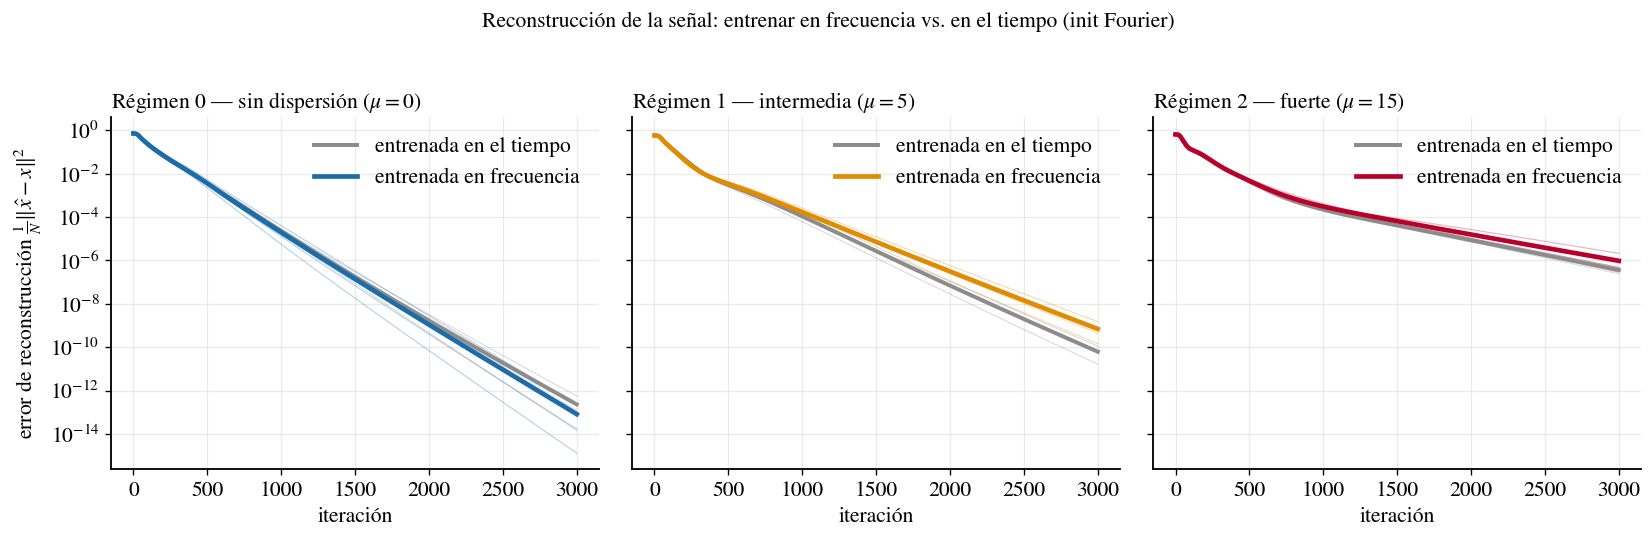

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.4), sharey=True)
it = np.arange(N_ITER)
for ax, reg in zip(axes, (0, 1, 2)):
    RF = res_freq[reg]["recon"];             mF = RF.mean(0)
    RS = resultados[reg]["fourier"]["loss"]; mS = RS.mean(0)
    for s in range(N_SEEDS):
        ax.semilogy(it, RS[s], color=COLOR_RANDOM, lw=0.7, alpha=0.30)
        ax.semilogy(it, RF[s], color=COLOR_REG[reg], lw=0.7, alpha=0.30)
    ax.semilogy(it, mS, color=COLOR_RANDOM, lw=2.4, label="entrenada en el tiempo")
    ax.semilogy(it, mF, color=COLOR_REG[reg], lw=2.8, label="entrenada en frecuencia")
    ax.set_title(NOMBRE_REG[reg], loc="left")
    ax.set_xlabel("iteración")
    ax.legend()
axes[0].set_ylabel(r"error de reconstrucción $\frac{1}{N}\|\hat x-x\|^2$")
fig.suptitle("Reconstrucción de la señal: entrenar en frecuencia vs. en el tiempo (init Fourier)", y=1.02)
fig.tight_layout()
plt.show()

## 5.4 Por qué son equivalentes: Parseval
Con $\Phi$ ortonormal, el error en frecuencia y el error de reconstrucción en el tiempo son **la misma cantidad**:

$$\lVert\Phi^\top\hat y - x\rVert^2=\lVert\Phi^\top(\hat y-\Phi x)\rVert^2=\lVert\hat y-\Phi x\rVert^2=N\,\mathcal{L}_{\text{freq}}.$$

Lo verificamos numéricamente en los pesos finales:

In [24]:
reg = 0
p   = res_freq[reg]["params_last"]
Xr  = jnp.asarray(X_all[y_all == reg])
Xf  = Xr @ Phi_j.T
L_freq  = float(jnp.mean((forward(p, Xr) - Xf) ** 2))          # error en frecuencia
L_recon = float(jnp.mean((forward(p, Xr) @ Phi_j - Xr) ** 2))  # error en el tiempo
print(f"L_freq (en frecuencia)      = {L_freq:.6e}")
print(f"L_recon (en el tiempo)      = {L_recon:.6e}")
print(f"|L_freq - L_recon|          = {abs(L_freq - L_recon):.2e}   -> idénticos (Parseval)")

L_freq (en frecuencia)      = 1.686266e-14
L_recon (en el tiempo)      = 1.686266e-14
|L_freq - L_recon|          = 2.56e-23   -> idénticos (Parseval)


## 5.5 La red aprendió el espectro
Izquierda: la reconstrucción $\hat x=\Phi^\top\hat y$ sobre la señal original. Derecha: el espectro aprendido $\hat y$ frente al espectro real $\Phi x$ (primeros coeficientes, donde vive la energía).

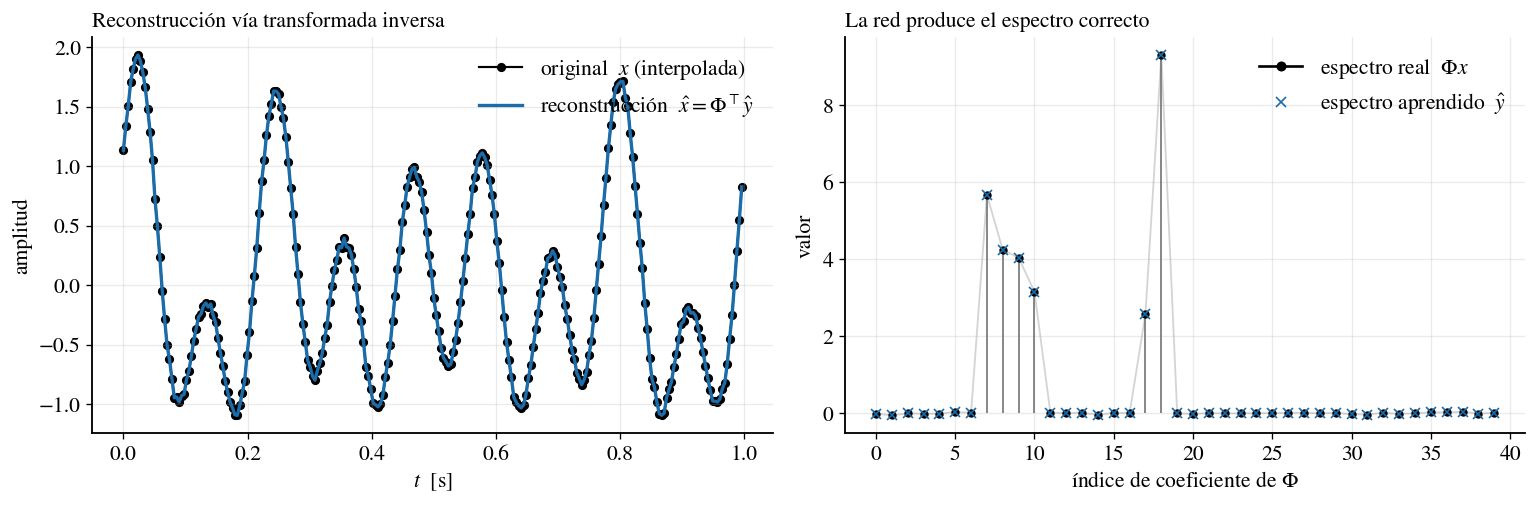

In [25]:
reg = 0
p   = res_freq[reg]["params_last"]
idx = np.where(y_all == reg)[0][0]
x   = X_all[idx]
yhat   = np.asarray(forward(p, jnp.asarray(x[None, :])))[0]   # espectro aprendido
xhat   = yhat @ Phi                                           # reconstrucción (inversa)
target = Phi @ x                                             # espectro real

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
dibujar_original(axes[0], t, x, label=r"original  $x$ (interpolada)")
axes[0].plot(t, xhat, "-", color=COLOR_REG[reg], lw=2.0, zorder=3,
             label=r"reconstrucción  $\hat x=\Phi^\top\hat y$")
axes[0].set_xlabel(r"$t$  [s]")
axes[0].set_ylabel("amplitud")
axes[0].set_title("Reconstrucción vía transformada inversa", loc="left")
axes[0].legend(loc="upper right")

m = 40
coef = np.arange(m)
# espectro real como stem (discreto); espectro aprendido como marcadores encima
# silueta tenue del espectro real (recta entre puntos, por detrás)
axes[1].plot(coef, target[:m], color="0.45", lw=1.1, alpha=0.30, zorder=1)
ml, sl, bl = axes[1].stem(coef, target[:m], basefmt=" ")
plt.setp(sl, color="0.45", lw=1.0)
plt.setp(ml, color="k", markersize=4)
axes[1].plot(coef, yhat[:m], marker="x", linestyle="none", markersize=5.5,
             color=COLOR_REG[reg])
axes[1].set_xlabel(r"índice de coeficiente de $\Phi$")
axes[1].set_ylabel("valor")
axes[1].set_title("La red produce el espectro correcto", loc="left")
from matplotlib.lines import Line2D
h_esp = [Line2D([0], [0], color="k", lw=1.6, marker="o", ms=5,
                label=r"espectro real  $\Phi x$"),
         Line2D([0], [0], color=COLOR_REG[reg], lw=0, marker="x", ms=6,
                label=r"espectro aprendido  $\hat y$")]
axes[1].legend(handles=h_esp, loc="upper right")
fig.tight_layout()
plt.show()

## 5.6 Lectura del experimento

- Entrenar la red para reconstruir el **espectro** $\Phi x$ y luego invertir ($\hat x=\Phi^\top\hat y$) reconstruye la señal **igual de bien** que entrenar directamente en el tiempo.
- La razón es **Parseval**: como $\Phi$ es ortonormal, el error en frecuencia y el error en el tiempo son *la misma cantidad* (verificado, $|L_{\text{freq}}-L_{\text{recon}}|\sim 10^{-16}$). Cambiar el espacio de la pérdida no cambia la geometría del problema, sólo el sistema de coordenadas.
- El **régimen 2 sigue topando** en el mismo nivel: el cuello de botella $K=15$ no alcanza sus frecuencias (15–19 Hz), da igual en qué espacio se mida el error.

Es decir: la base de Fourier no sólo es un buen *punto de partida* (Parte III); además define un espacio de trabajo (el de frecuencias) **equivalente** al del tiempo para esta tarea, lo que refuerza por qué es una elección natural en este problema.

# Parte VI — Conclusiones

1. **La capa $W_1$ en su inicialización Fourier es exactamente la DFT** de la señal (parte real y parte imaginaria con signo), salvo el factor $2/N$ — verificado con error $\sim 10^{-15}$.

2. **Compresión.** Casi todas las señales necesitan **3–9 modos DFT** para acumular el 95 % de la energía. Es decir, $K=15$ es más que suficiente *en número de coeficientes*… **siempre que esas frecuencias estén dentro de la banda** $1\le k\le 15$.

3. **Régimen 0 — la base Fourier ayuda.** Las señales viven en frecuencias $1\le f\le 11$ Hz, exactamente donde apunta la base. A iteraciones tempranas (50, 100, 200) la pérdida media de la inicialización aleatoria es **5–9 % más alta** que la de Fourier, de forma consistente sobre las 3 semillas.

4. **Régimen 1 — Fourier sigue por delante.** Las frecuencias (5–12 Hz) siguen dentro de la base; la ventaja temprana es similar a la del régimen 0.

5. **Régimen 2 — la base Fourier ya *no* ayuda.** Los picos espectrales están entre **15 y 19 Hz**, *justo en o por encima* del corte $K=15$. Las dos inicializaciones se comportan esencialmente igual.

6. **Magnitudes esperables.** Como $W_1$ también se entrena, las dos inicializaciones acaban convergiendo a pérdidas muy parecidas; el "head-start" de Fourier sólo se nota en la **velocidad inicial**. Si $W_1$ estuviera *congelada* la diferencia sería mucho mayor.

7. **Aprender en frecuencia (Parte V).** Entrenar la red para reproducir el **espectro** $\Phi x$ y reconstruir con la transformada inversa da el mismo resultado que entrenar en el tiempo. Por **Parseval** (con $\Phi$ ortonormal) ambos errores son idénticos: la base de Fourier define un espacio de trabajo equivalente al del tiempo para esta tarea.

**Respuesta a la pregunta guía.** Arrancar en la base "correcta" (Fourier) **sí ayuda**, *pero sólo cuando "correcta" es realmente correcta*: las señales deben caber en la banda de frecuencias que la base cubre. El experimento muestra el caso ideal (régimen 0) y el contraejemplo (régimen 2), evidencia de que la elección de la base inicial es una decisión informada por el dominio, no una receta universal.